# Example-25: Frequency from shifted signals (method)

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Set parameters

size, length = 2, 2**15

# Set window

w = Window.from_cosine(length, order=1.0, dtype=dtype, device=device)

# Set TbT

t = torch.linspace(1, length, length, dtype=dtype, device=device)
x = 0.75*torch.cos(2.0*numpy.pi*0.12*t + 0.10)
y = 0.50*torch.cos(2.0*numpy.pi*0.31*t + 0.50)
d = Data.from_data(w, torch.stack([x, y]))

# Add noise

d.add_noise(torch.tensor([1.0E-2, 1.0E-4], dtype=dtype, device=device))

# Estimate frequency from shifted signals
# Note, work is used in task_shift(), window is applied inside

f = Frequency(d)
out = f.compute_shifted_frequency(1024, 8)
print(out.shape)

torch.Size([2, 3969])


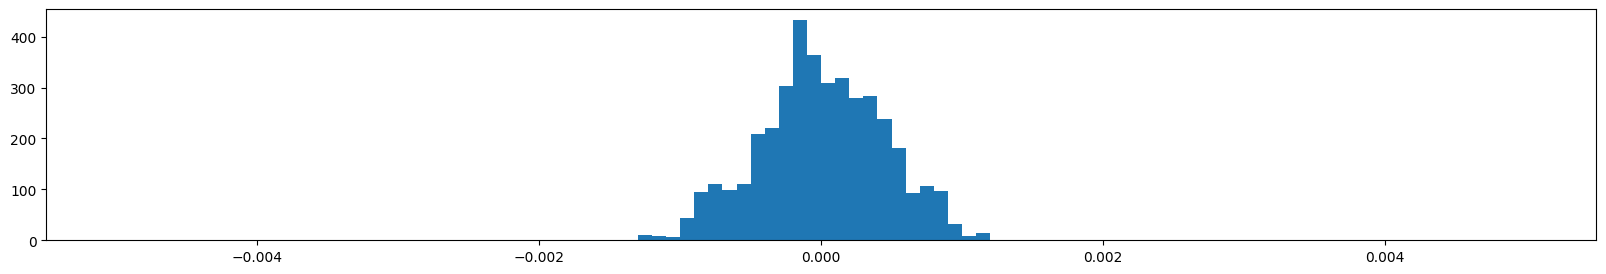

tensor(2.904813088497e-06, dtype=torch.float64)


In [4]:
# Plot result (1st signal)

plt.figure(figsize=(20, 3))
plt.hist((out[0].cpu().numpy()-0.12)/0.12 * 100, bins=100, range=(-0.005, 0.005))
plt.show()
print(out[0].max() - out[0].min())

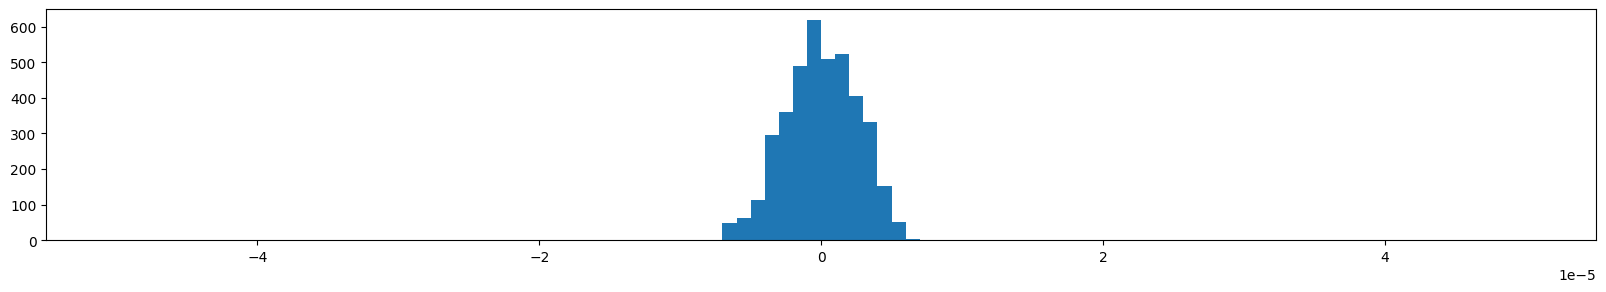

tensor(4.039359086105e-08, dtype=torch.float64)


In [5]:
# Plot result (2nd signal)

plt.figure(figsize=(20, 3))
plt.hist((out[1].cpu().numpy()-0.31)/0.31 * 100, bins=100, range=(-0.00005, 0.00005))
plt.show()
print(out[1].max() - out[1].min())